In [ ]:
import pandas as pd
import numpy as np
# Load dataset
df = pd.read_csv("diamonds.csv")
print("Shape:", df.shape)
df.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
# Replace zero dimensions with NaN
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
df.dropna(inplace=True)

# Convert USD to INR
USD_TO_INR = 83
df['price_inr'] = df['price'] * USD_TO_INR

print("New Shape:", df.shape)

New Shape: (53920, 11)


In [ ]:
num_cols = ['carat', 'price_inr', 'x', 'y', 'z']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape After Outlier Removal:", df.shape)

Shape After Outlier Removal: (49498, 11)


In [ ]:
# Log transformation for better prediction
df['log_price'] = np.log1p(df['price_inr'])

# New Features
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price_inr'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# Carat Category
def carat_category(carat):
    if carat < 0.5:
        return "Light"
    elif 0.5 <= carat <= 1.5:
        return "Medium"
    else:
        return "Heavy"

df['carat_category'] = df['carat'].apply(carat_category)

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,log_price,volume,price_per_carat,dimension_ratio,carat_category
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,27058,10.205775,38.202030,117643.478261,1.631687,Light
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,27058,10.205775,34.505856,128847.619048,1.673160,Light
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,27141,10.208838,38.076885,118004.347826,1.757576,Light
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,27722,10.230018,46.724580,95593.103448,1.602662,Light
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,27805,10.233007,51.917250,89693.548387,1.580000,Light


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

df[['cut','color','clarity']] = encoder.fit_transform(
    df[['cut','color','clarity']]
)

df['carat_category'] = df['carat_category'].map({
    'Light':0,
    'Medium':1,
    'Heavy':2
})

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['carat','cut','color','clarity','depth','table',
        'x','y','z','volume','dimension_ratio','carat_category']]

y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 0.10816206762196671
RMSE: 0.13966370937963024
R2: 0.9760101001967647


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.9820066049862439


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9907084055480136


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, y_pred_knn))

KNN R2: 0.9800338382357069


In [ ]:
!pip install xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost R2: 0.9909392259319486


In [ ]:
models = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "XGBoost": y_pred_xgb
}

results = []

for name, preds in models.items():
    results.append([
        name,
        mean_absolute_error(y_test, preds),
        np.sqrt(mean_squared_error(y_test, preds)),
        r2_score(y_test, preds)
    ])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
4,XGBoost,0.061918,0.085833,0.990939
2,Random Forest,0.061235,0.086919,0.990708
1,Decision Tree,0.081737,0.120956,0.982007
3,KNN,0.095672,0.127414,0.980034
0,Linear Regression,0.108162,0.139664,0.976010


In [ ]:
import pickle

with open("best_price_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
cluster_df = df[['carat','cut','color','clarity','depth','table',
                 'x','y','z','volume','dimension_ratio','carat_category']]

from sklearn.preprocessing import StandardScaler
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_df)

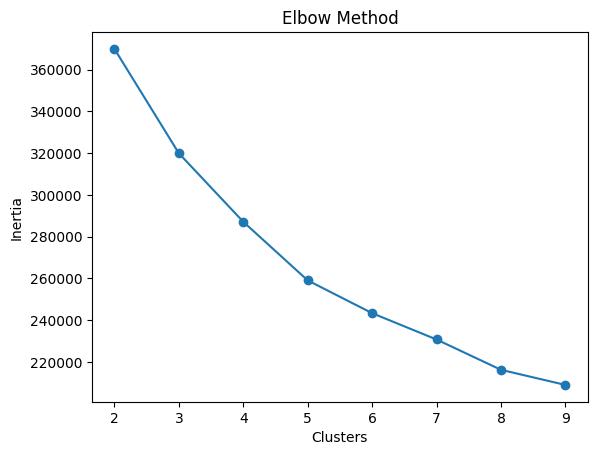

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(cluster_scaled)

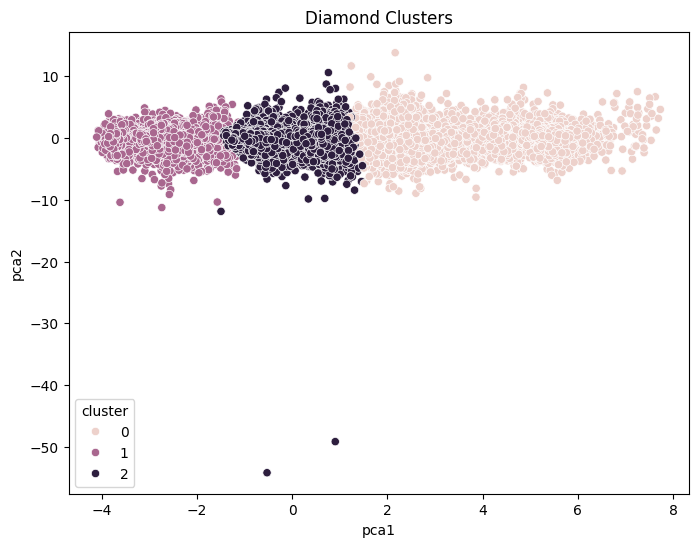

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_components = pca.fit_transform(cluster_scaled)

df['pca1'] = pca_components[:,0]
df['pca2'] = pca_components[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df)
plt.title("Diamond Clusters")
plt.show()

In [ ]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("cluster_scaler.pkl", "wb") as f:
    pickle.dump(scaler_cluster, f)

print("Model Saved Successfully!")

Model Saved Successfully!
